In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/10000
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  38.65531916219593
RUN  2 , total integrated cost =  34.40807204566082
RUN  3 , total integrated cost =  29.45915285516994
RUN  4 , total integrated cost =  26.82517121239512
RUN  5 , total integrated cost =  24.19409228727611
RUN  6 , total integrated cost =  22.592310276620356
RUN  7 , total integrated cost =  21.078453897215393
RUN  8 , total integrated cost =  19.991434277179337
RUN  9 , total integrated cost =  18.920532633406886
RUN  10 , total integrated cost =  17.937931256283733
RUN  11 , total integrated cost =  16.845823042014143
RUN  12 , total integrated cost =  15.701644183716546
RUN  13 , total integrated cost =  14.321810672783487
RUN  14 , total integrated cost =  11.716753059827226
RUN  15 , total integrated cost =  11.534883537351565
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  89 , total integrated cost =  9.580902256825704
Improved over  89  iterations in  13.240315992385149  seconds by  99.83767803368802  percent.
Problem in initial value trasfer:  Vmean_exc -64.40443389659825 -64.39513677575553
weight =  6160.595652704153
set cost params:  1.0 0.0 6160.595652704153
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5708.930816089737
Gradient descend method:  None
RUN  1 , total integrated cost =  5468.329020177764
RUN  2 , total integrated cost =  5467.864797233239
RUN  3 , total integrated cost =  5467.844897294314
RUN  4 , total integrated cost =  5467.840400617908
RUN  5 , total integrated cost =  5467.83773652098
RUN  6 , total integrated cost =  5467.83615040551
RUN  7 , total integrated cost =  5467.833549111412
RUN  8 , total integrated cost =  5467.828096147685
RUN  9 , total integrated cost =  5467.798575008105
RUN  10 , total integrated cost =  5464.557658093003
RUN  11 , total integrate

ERROR:root:Problem in initial value trasfer


RUN  17 , total integrated cost =  5459.3410228655075
RUN  18 , total integrated cost =  5459.341022865506
RUN  19 , total integrated cost =  5459.341022865505
RUN  20 , total integrated cost =  5459.341022865505
Control only changes marginally.
RUN  20 , total integrated cost =  5459.341022865505
Improved over  20  iterations in  0.5101083312183619  seconds by  4.371918337507296  percent.
Problem in initial value trasfer:  Vmean_exc -61.64176241398166 -61.67481109659468
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  1 , total integrated cost =  99.89721709625324
RUN  2 , total integrated cost =  84.54274930738343
RUN  3 , total integrated cost =  65.5844521085687
RUN  4 , total integrated cost =  58.73917124439824
RUN  5 , total integrated cost =  51.36921169939225
RUN  6 , total integrated cost =  46.68737733830355
RUN  7 , t

...

RUN  13 , total integrated cost =  13270.690302911134
RUN  14 , total integrated cost =  13270.690302911127
RUN  15 , total integrated cost =  13270.690302911118
RUN  16 , total integrated cost =  13270.690302911114
State only changes marginally.
RUN  17 , total integrated cost =  13270.690302911114
Control only changes marginally.
RUN  17 , total integrated cost =  13270.690302911114
Improved over  17  iterations in  0.4554768353700638  seconds by  6.7773771374968135  percent.
Problem in initial value trasfer:  Vmean_exc -59.38041919405046 -59.39883906940352
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10019.968518582271
Gradient descend method:  None
RUN  1 , total integrated cost =  70.38536497166969
RUN  2 , total integrated cost =  59.92135227072147
RUN  3 , total integrated cost =  47.249894918660964
RUN  4 , total integrated cost =  41.812521331903035
RUN  5 , total integ

ERROR:root:Problem in initial value trasfer


RUN  90 , total integrated cost =  16.769001955620936
Control only changes marginally.
RUN  92 , total integrated cost =  16.769001955620922
Improved over  92  iterations in  2.003149177879095  seconds by  99.83264416525338  percent.
Problem in initial value trasfer:  Vmean_exc -72.64644822513253 -72.68673047538377
weight =  5975.292116430105
set cost params:  1.0 0.0 5975.292116430105
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9923.057688627276
Gradient descend method:  None
RUN  1 , total integrated cost =  9398.947437590143
RUN  2 , total integrated cost =  9398.800464973592
RUN  3 , total integrated cost =  9398.796703557304
RUN  4 , total integrated cost =  9398.796447802262
RUN  5 , total integrated cost =  9398.79644344186
RUN  6 , total integrated cost =  9398.796441862722
RUN  7 , total integrated cost =  9398.79644121705
RUN  8 , total integrated cost =  9398.796440949673
RUN  9 , total integrated cost =  9398.796440829798
RUN  10 , total integrat

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  27 , total integrated cost =  9398.796440732714
Improved over  27  iterations in  0.6316140443086624  seconds by  5.283263126600701  percent.
Problem in initial value trasfer:  Vmean_exc -61.78121201118947 -61.83033832102625


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


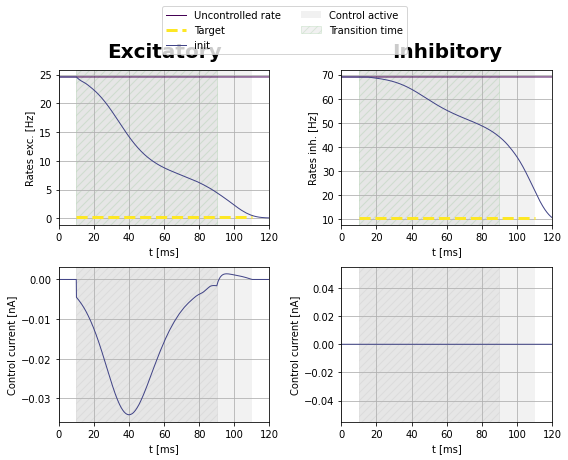

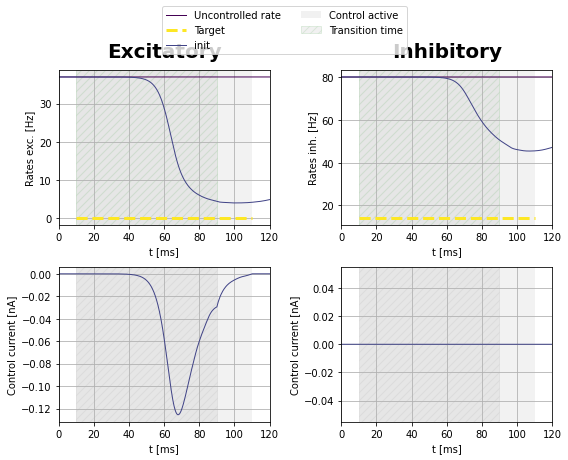

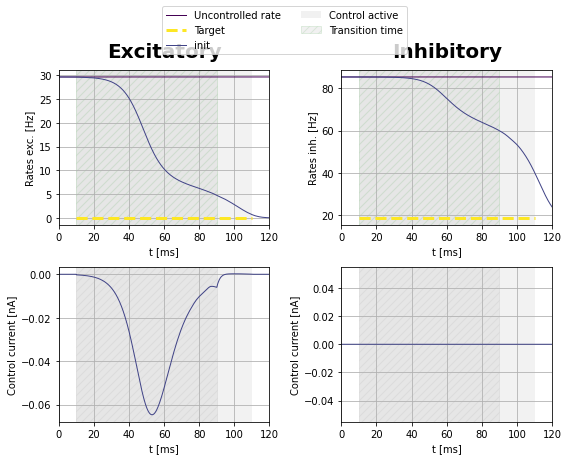

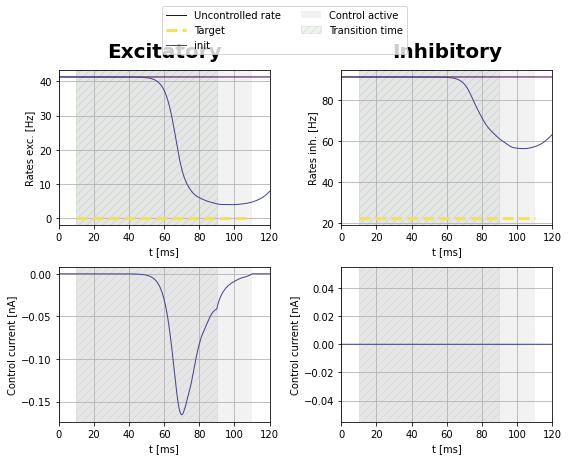

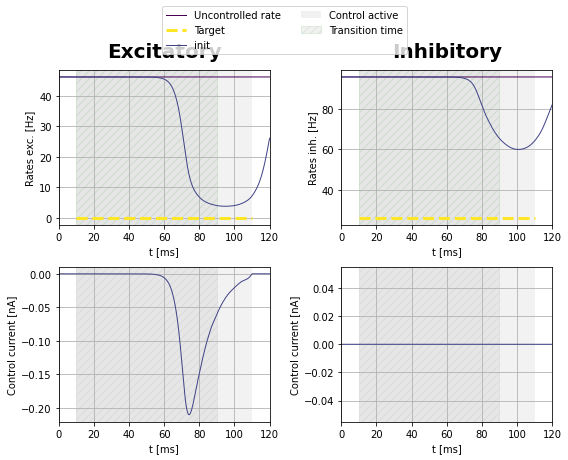

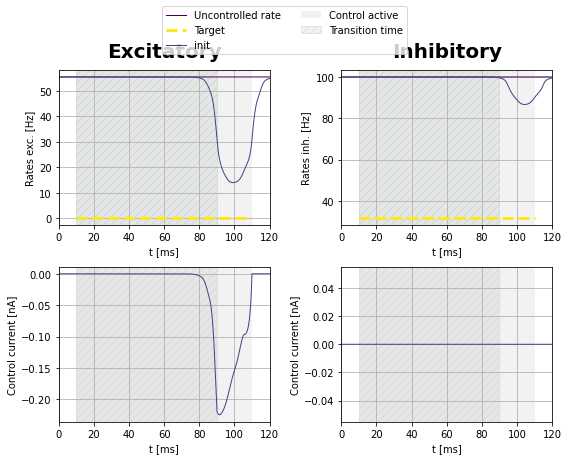

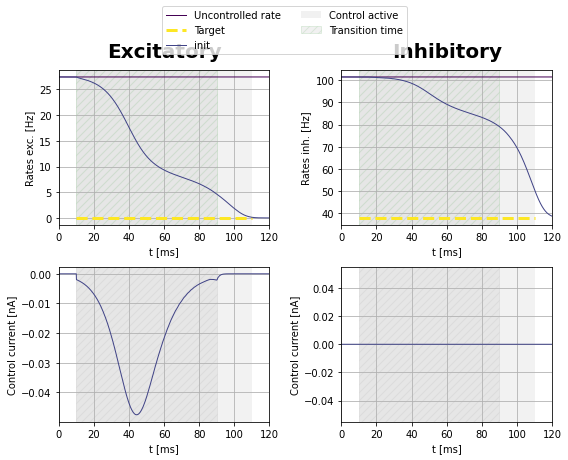

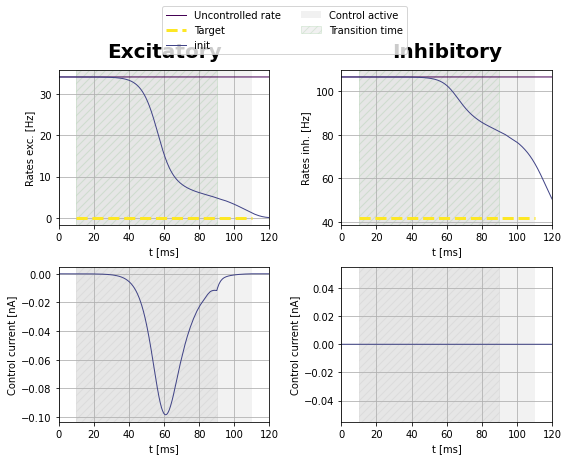

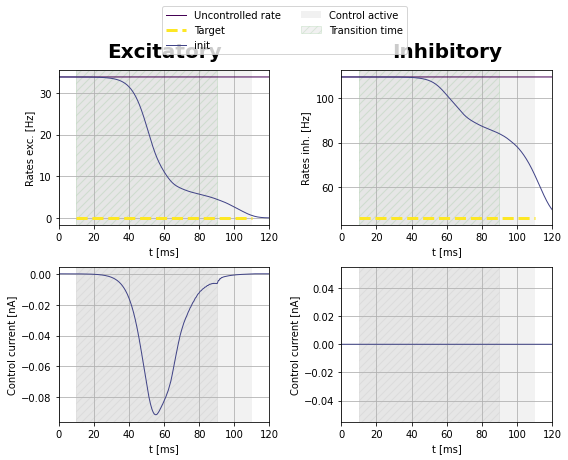

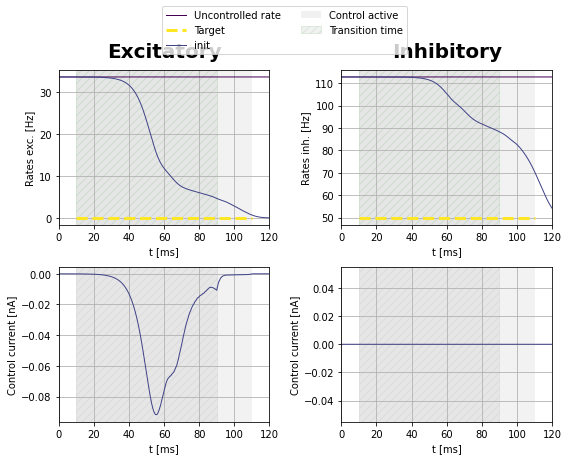

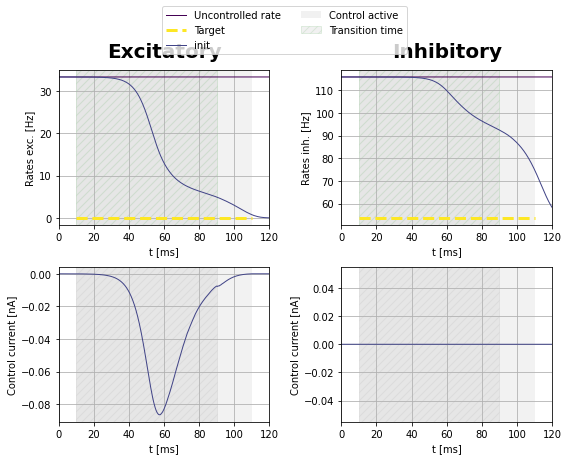

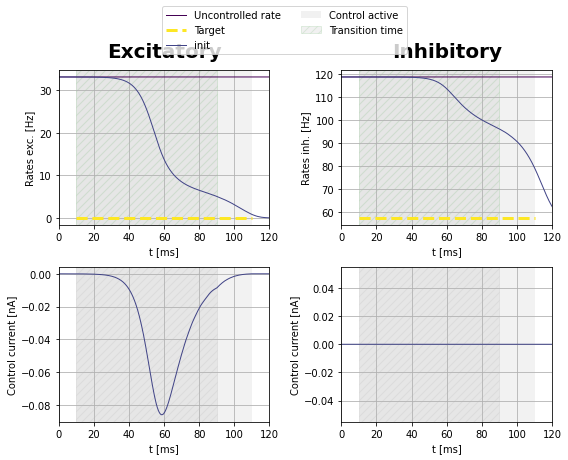

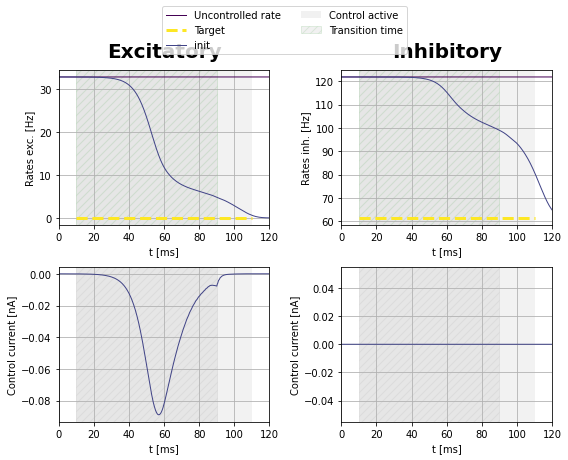

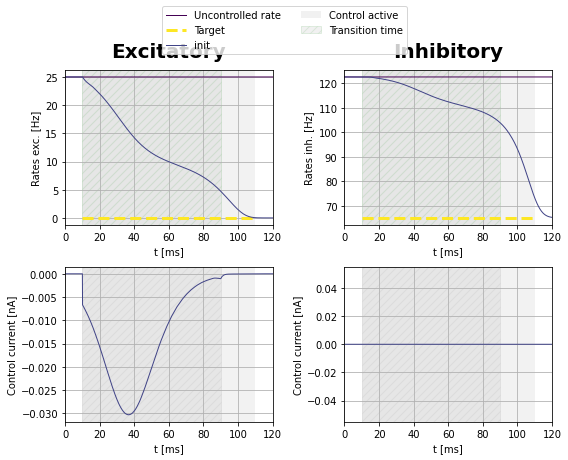

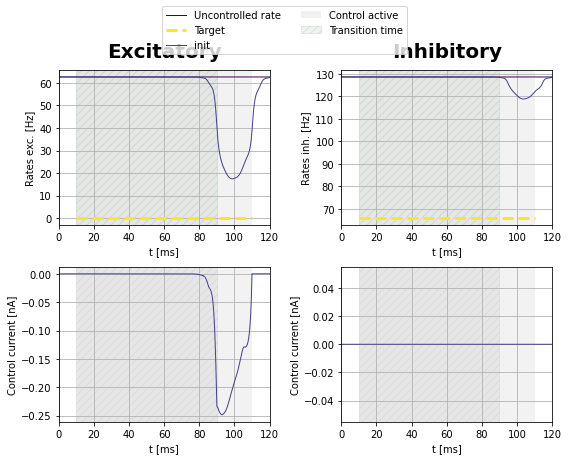

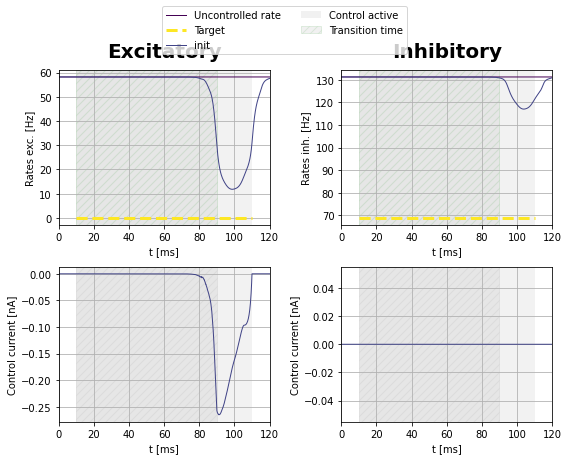

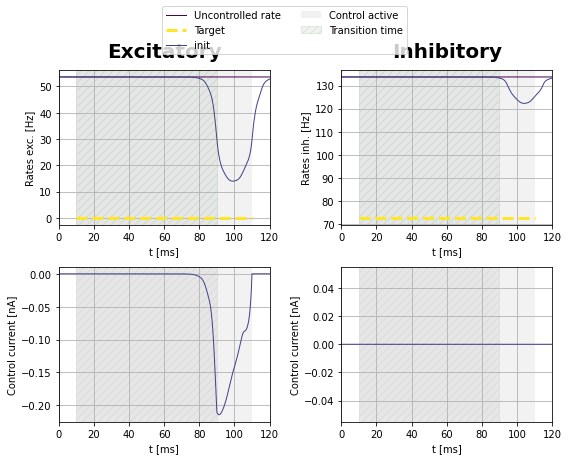

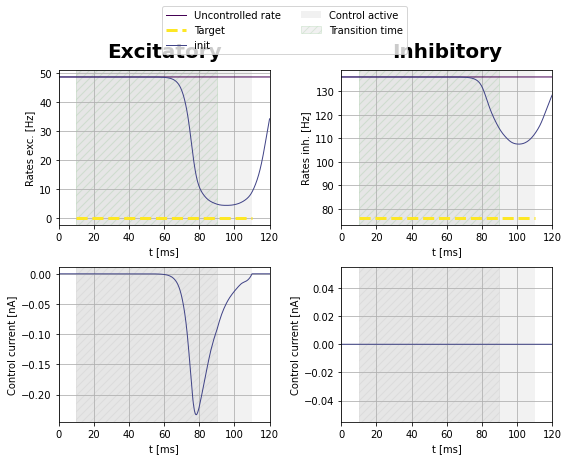

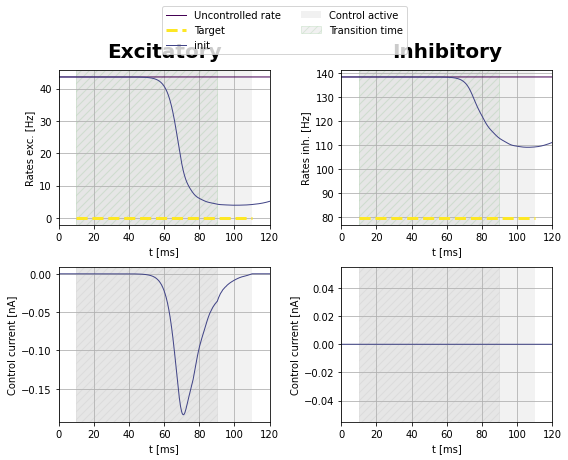

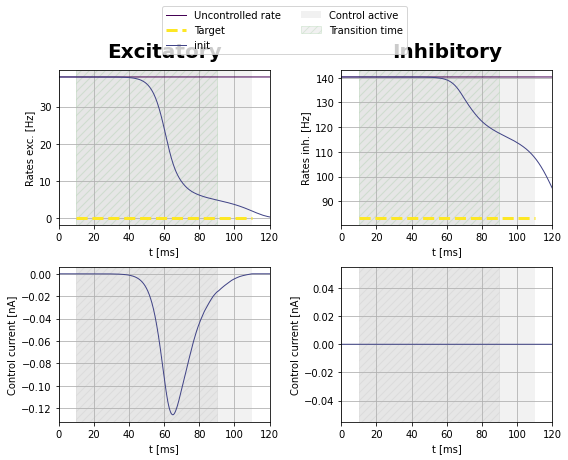

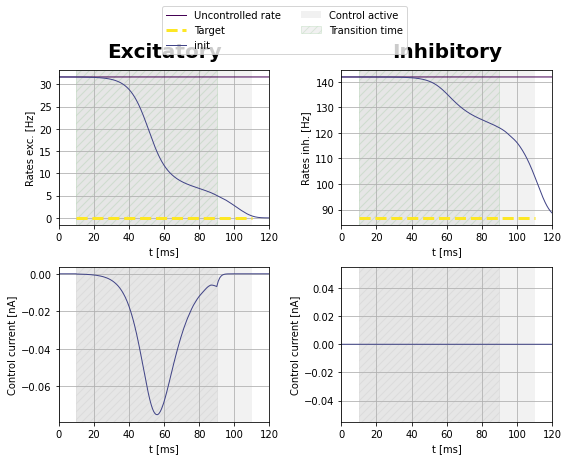

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
found solution for  7
-------  14 0.4250000000000001 0.4500000000000002
found solution for  14
-------  

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  38.569467628959785
Control only changes marginally.
RUN  42 , total integrated cost =  38.56946762895978
Improved over  42  iterations in  0.9141629748046398  seconds by  99.76294575322922  percent.
Problem in initial value trasfer:  Vmean_exc -65.83857392206492 -65.8487257609924
weight =  5525.897579659459
set cost params:  1.0 0.0 5525.897579659459
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20968.273862949693
Gradient descend method:  None
RUN  1 , total integrated cost =  19717.32111345503
RUN  2 , total integrated cost =  19717.271559172696
RUN  3 , total integrated cost =  19717.134877153432
RUN  4 , total integrated cost =  19715.94394776102
RUN  5 , total integrated cost =  19715.659686513733
RUN  6 , total integrated cost =  19715.627262896705
RUN  7 , total integrated cost =  19715.51161126295
RUN  8 , total integrated cost =  19714.388331154354
RUN  9 , total integrated cost =  19714.065741232887
RUN  10 , total 

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  19700.12651692968
RUN  14 , total integrated cost =  19700.12651692968
Control only changes marginally.
RUN  14 , total integrated cost =  19700.12651692968
Improved over  14  iterations in  0.37329270876944065  seconds by  6.047933913438584  percent.
Problem in initial value trasfer:  Vmean_exc -57.71682711622611 -57.70567762126453
-------  35 0.5500000000000003 0.5250000000000002
[0, 7, 14, 21] []
closest index  21
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  27386.764437755028
Gradient descend method:  None
RUN  1 , total integrated cost =  152.86698192709486
RUN  2 , total integrated cost =  136.66364973612804
RUN  3 , total integrated cost =  111.12614102133793
RUN  4 , total integrated cost =  100.94321755666304
RUN  5 , total integrated cost =  88.76878906746734
RUN  6 , total integrated cost =  82.56483588849298
RUN  7 , total integrated cost =  75.61581431047075
R

...

RUN  50 , total integrated cost =  27891.909780555725
Control only changes marginally.
RUN  55 , total integrated cost =  27890.58170921346
Improved over  55  iterations in  1.2548232953995466  seconds by  15.101887764079493  percent.
Problem in initial value trasfer:  Vmean_exc -56.66609411241469 -56.66970232434858
-------  112 0.5500000000000003 0.8000000000000005
[0, 7, 14, 21, 42, 49, 56, 63, 70, 77, 84, 91, 126, 133, 140, 119, 28] [84, 126, 133, 119, 91, 77, 140, 70, 63, 56, 49, 42, 21, 14, 7, 28]
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28848.363119479927
Gradient descend method:  None
RUN  1 , total integrated cost =  181.17338220463063
RUN  2 , total integrated cost =  135.534038053745
RUN  3 , total integrated cost =  61.02423728995053
RUN  4 , total integrated cost =  59.004003126893465
RUN  5 , total integrated cost =  58.56388064308347
RUN  6 , total integrated cost =  57.60

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  104 , total integrated cost =  51.81002132527289
Improved over  104  iterations in  2.2322296146303415  seconds by  99.8204056808676  percent.
Problem in initial value trasfer:  Vmean_exc -65.07760741531945 -65.10024275557578
weight =  5542.468637381228
set cost params:  1.0 0.0 5542.468637381228
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  27706.5794552824
Gradient descend method:  None
RUN  1 , total integrated cost =  24934.08879121163
RUN  2 , total integrated cost =  24913.68581000201
RUN  3 , total integrated cost =  24889.069915486107
RUN  4 , total integrated cost =  24869.3306489481
RUN  5 , total integrated cost =  24841.921786175175
RUN  6 , total integrated cost =  24819.382778453906
RUN  7 , total integrated cost =  24786.679997356685
RUN  8 , total integrated cost =  24758.211498350658
RUN  9 , total integrated cost =  24659.912572157315
RUN  10 , total integrated cost =  24587.154593130595
RUN  11 , total i

ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  23319.85687164562
Control only changes marginally.
RUN  107 , total integrated cost =  23319.852291599786
Improved over  107  iterations in  2.2931421995162964  seconds by  15.832799464699946  percent.
Problem in initial value trasfer:  Vmean_exc -56.64262294171379 -56.645305427951286
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.8750000000000006
-------  140 0.4500000000000001 0.9000000000000006
------------------------------------------------------------
-------------------- 17
------------------------------------------------------------
found solution:  [0, 7, 14, 21, 42, 49, 56, 63, 70, 77, 84, 91, 126, 133, 140, 119, 28]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.50000000

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6659.573051617666
set cost params:  1.0 0.0 6659.573051617666
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5896.940088308446
Gradient descend method:  None
RUN  1 , total integrated cost =  5896.813602780639
RUN  2 , total integrated cost =  5896.809558368179
RUN  3 , total integrated cost =  5896.809319874595
RUN  4 , total integrated cost =  5896.809310088474
RUN  5 , total integrated cost =  5896.809308402803
RUN  6 , total integrated cost =  5896.80930833121
RUN  7 , total integrated cost =  5896.809308327944


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  5896.80930832794
RUN  9 , total integrated cost =  5896.80930832794
Control only changes marginally.
RUN  9 , total integrated cost =  5896.80930832794
Improved over  9  iterations in  0.2657732870429754  seconds by  0.0022177600339858827  percent.
Problem in initial value trasfer:  Vmean_exc -61.47767335722339 -61.51069879167383
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  5630.858183179979
set cost params:  1.0 0.0 5630.858183179979
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13537.400654737015
Gradient descend method:  None
RUN  1 , total integrated cost =  13536.505583600117
RUN  2 , total integrated cost =  13536.488109884176
RUN  3 , total integrated cost =  13536.486094824744
RUN  4 , total integrated cost =  13536.485631992915
RUN  5 , total integrated cost =  13536.485418562665


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  13536.485388739302
RUN  7 , total integrated cost =  13536.485376961946
RUN  8 , total integrated cost =  13536.485376961944
RUN  9 , total integrated cost =  13536.48537696194
RUN  10 , total integrated cost =  13536.48537696194
Control only changes marginally.
RUN  10 , total integrated cost =  13536.48537696194
Improved over  10  iterations in  0.3399039711803198  seconds by  0.0067611042800450605  percent.
Problem in initial value trasfer:  Vmean_exc -57.884391803242366 -57.88134738756037
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  6172.784658081519
set cost params:  1.0 0.0 6172.784658081519
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8788.380393680976
Gradient descend method:  None
RUN  1 , total integrated cost =  8788.379424529976
RUN  2 , total integrated cost =  8788.379346697075
RUN  3 , total integrated cost =  8788.379339644267
RUN  4 , total integrated cost =  8788.37933914549
RUN

...

RUN  3 , total integrated cost =  39105.289993708444
RUN  4 , total integrated cost =  39105.28999370843
RUN  5 , total integrated cost =  39105.28999370843
Control only changes marginally.
RUN  5 , total integrated cost =  39105.28999370843
Improved over  5  iterations in  0.22097316570580006  seconds by  0.0016180560837568692  percent.
Problem in initial value trasfer:  Vmean_exc -56.70225987495399 -56.70204200917909
-------  105 0.5750000000000002 0.7750000000000005
no convergence
weight =  8445.527293040494
set cost params:  1.0 0.0 8445.527293040494
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33794.1943051118
Gradient descend method:  None
RUN  1 , total integrated cost =  33793.825140101544
RUN  2 , total integrated cost =  33793.82468917915


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  33793.82468790143
RUN  4 , total integrated cost =  33793.82468789698
RUN  5 , total integrated cost =  33793.824687896966
RUN  6 , total integrated cost =  33793.82468789696
RUN  7 , total integrated cost =  33793.82468789695
RUN  8 , total integrated cost =  33793.82468789695
Control only changes marginally.
RUN  8 , total integrated cost =  33793.82468789695
Improved over  8  iterations in  0.2791837155818939  seconds by  0.0010937299215072471  percent.
Problem in initial value trasfer:  Vmean_exc -56.704194123715006 -56.70415357509367
-------  112 0.5500000000000003 0.8000000000000005
no convergence
weight =  8061.513067178482
set cost params:  1.0 0.0 8061.513067178482
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28635.83632590844
Gradient descend method:  None
RUN  1 , total integrated cost =  28635.48978139037
RUN  2 , total integrated cost =  28635.486805954817
RUN  3 , total integrated cost =  28635.486768352723
RUN 

ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  28635.486768249622
RUN  10 , total integrated cost =  28635.486768249622
Control only changes marginally.
RUN  10 , total integrated cost =  28635.486768249622
Improved over  10  iterations in  0.26756007596850395  seconds by  0.0012207000167165916  percent.
Problem in initial value trasfer:  Vmean_exc -56.703139670294114 -56.70324826909511
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  69.82497271359516
Gradient descend method:  None
RUN  1 , total integrated cost =  9.578103835462548
RUN  2 , total integrated cost =  9.57304696388843
RUN  3 , total integrated cost =  9.573031779559567
RUN  4 , total integrated cost =  9.573031388076009


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  9.573031388076009
Control only changes marginally.
RUN  5 , total integrated cost =  9.573031388076009
Improved over  5  iterations in  0.5586363449692726  seconds by  86.28996043100192  percent.
Problem in initial value trasfer:  Vmean_exc -64.44964531532851 -64.43995156173287
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  92.81325405362391
Gradient descend method:  HS
RUN  1 , total integrated cost =  92.07532572820759
RUN  2 , total integrated cost =  91.48680982813806
RUN  3 , total integrated cost =  90.92472132926534
RUN  4 , total integrated cost =  90.89412707799781
RUN  5 , total integrated cost =  90.89390323370674
RUN  6 , total integrated cost =  90.89389199904082
RUN  7 , total integrated cost =  90.8922199372778
RUN  8 , total integrated cost =  90.89219903964914
RUN  9 , total integrated cost =  90.8920546406468
RUN  10 , total integrated cost =  90.89205464064669
RUN

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  90.34189716014264
Control only changes marginally.
RUN  19 , total integrated cost =  90.34189716014264
Improved over  19  iterations in  2.691014328971505  seconds by  2.6627198008308426  percent.
Problem in initial value trasfer:  Vmean_exc -64.71203772660161 -64.70577114735357
weight =  6532.409929144624
set cost params:  1.0 0.0 6532.409929144624
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5859.802920249191
Gradient descend method:  None
RUN  1 , total integrated cost =  5758.941876850358
RUN  2 , total integrated cost =  5758.721708496834
RUN  3 , total integrated cost =  5758.721330866515
RUN  4 , total integrated cost =  5758.721330866512
RUN  5 , total integrated cost =  5758.7213308665105


...

RUN  8 , total integrated cost =  16.764768868390757
Control only changes marginally.
RUN  8 , total integrated cost =  16.764768868390757
Improved over  8  iterations in  0.9019651003181934  seconds by  85.40466164551125  percent.
Problem in initial value trasfer:  Vmean_exc -72.6507040688842 -72.69096608443982
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  166.18700138140818
Gradient descend method:  HS
RUN  1 , total integrated cost =  164.01773009241677
RUN  2 , total integrated cost =  162.90324787147924
RUN  3 , total integrated cost =  161.5593036198889
RUN  4 , total integrated cost =  161.2468074313655
RUN  5 , total integrated cost =  161.21160859283086
RUN  6 , total integrated cost =  161.21109166428607
RUN  7 , total integrated cost =  161.2003070266812
RUN  8 , total integrated cost =  161.20027948240727
RUN  9 , total integrated cost =  161.19721704720772
RUN  10 , total integrated cost =  161.1972105

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  161.1972105476331
RUN  14 , total integrated cost =  161.1972105476331
Control only changes marginally.
RUN  14 , total integrated cost =  161.1972105476331
Improved over  14  iterations in  1.792247872799635  seconds by  3.002515715608382  percent.
Problem in initial value trasfer:  Vmean_exc -71.18949389932845 -71.23661996135338
weight =  6214.968926845302
set cost params:  1.0 0.0 6214.968926845302
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9945.83152650498
Gradient descend method:  None
RUN  1 , total integrated cost =  9712.587319737428
RUN  2 , total integrated cost =  9711.26713499094
RUN  3 , total integrated cost =  9711.266814431985
RUN  4 , total integrated cost =  9711.266814431972


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  9711.266814431972
Control only changes marginally.
RUN  5 , total integrated cost =  9711.266814431972
Improved over  5  iterations in  0.6745494101196527  seconds by  2.358422334501725  percent.
Problem in initial value trasfer:  Vmean_exc -62.79440020801327 -62.84976756783283


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


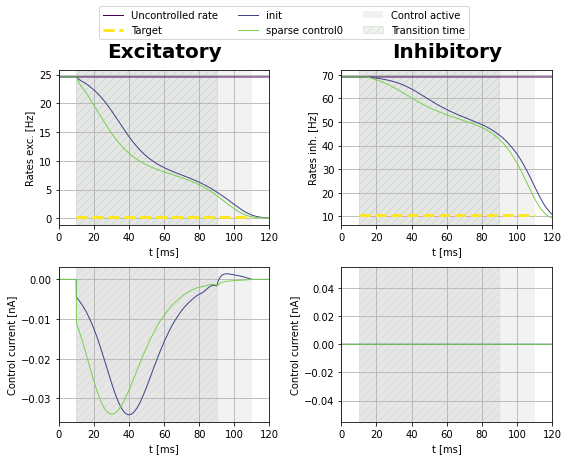

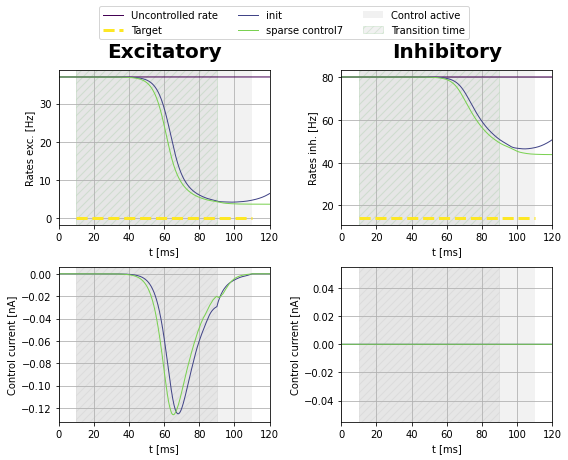

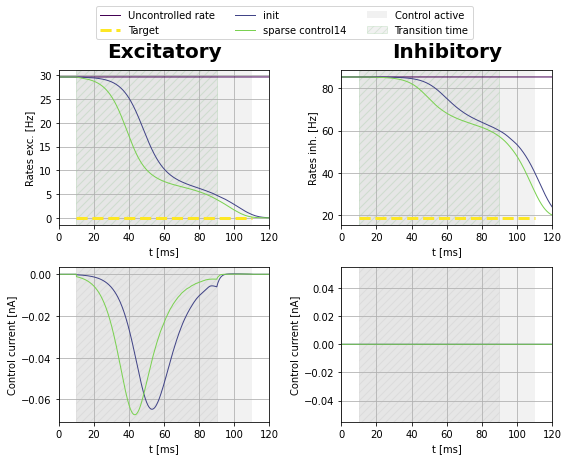

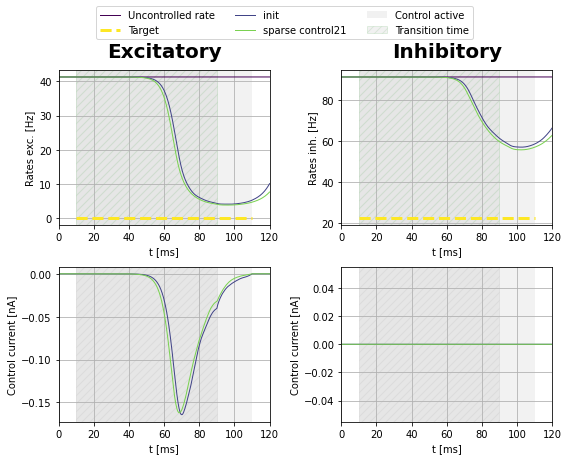

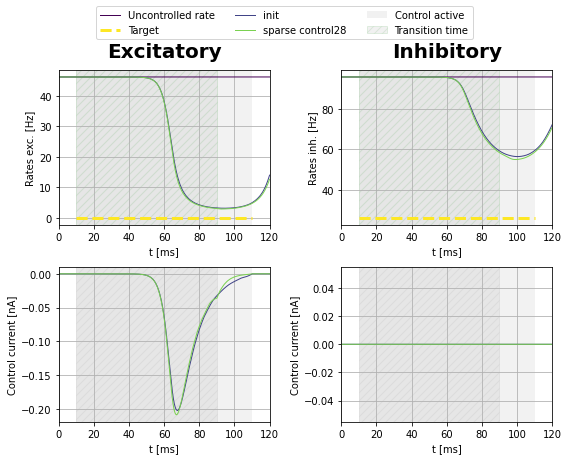

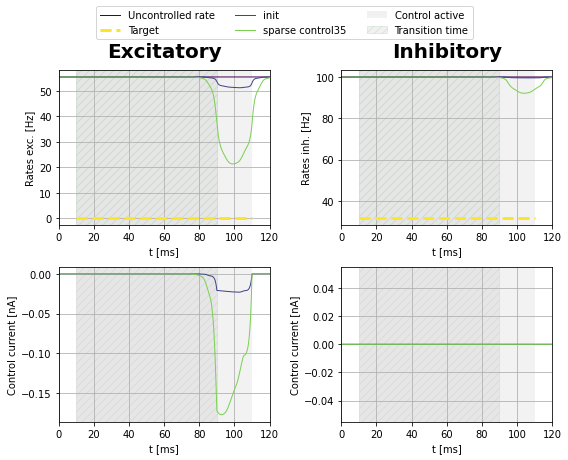

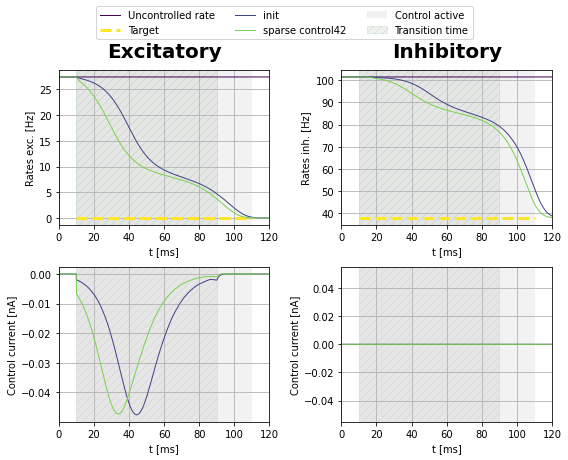

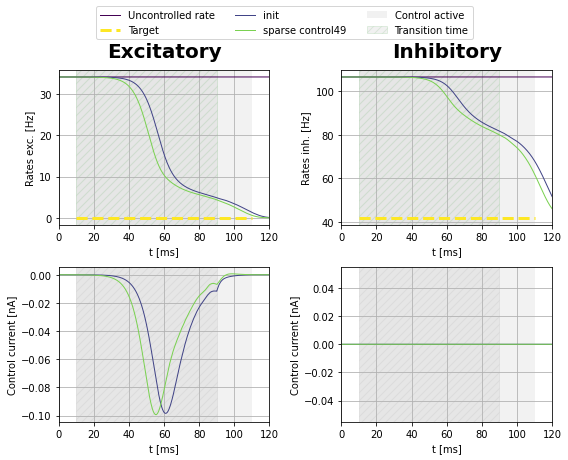

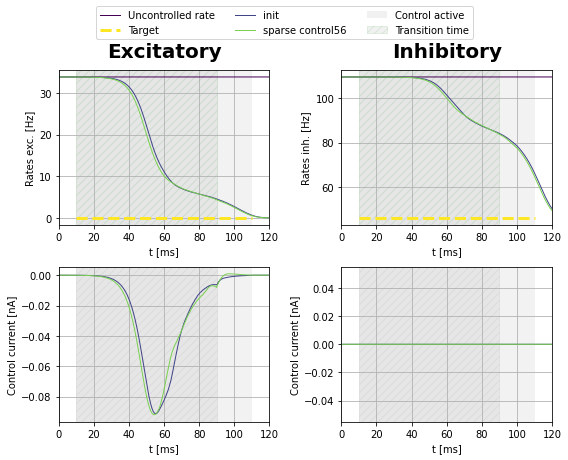

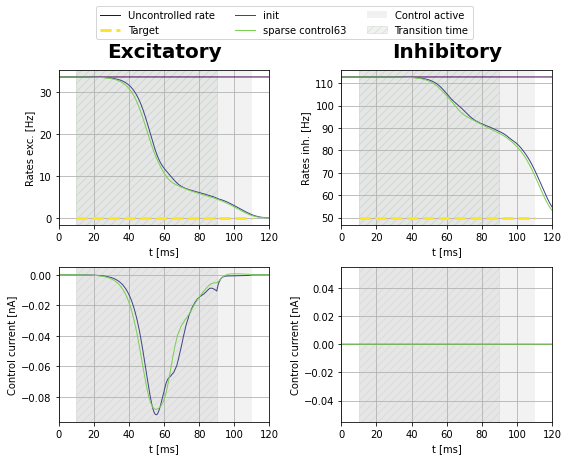

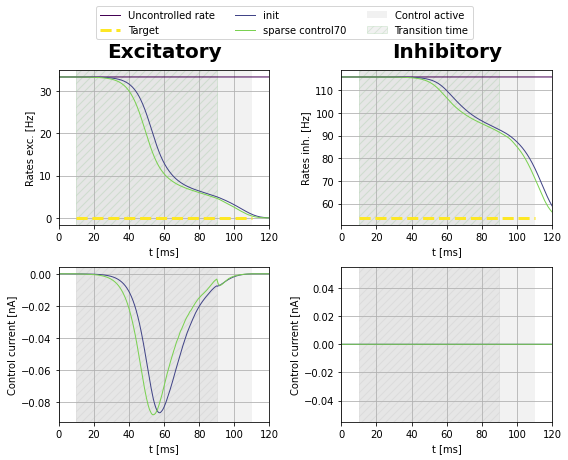

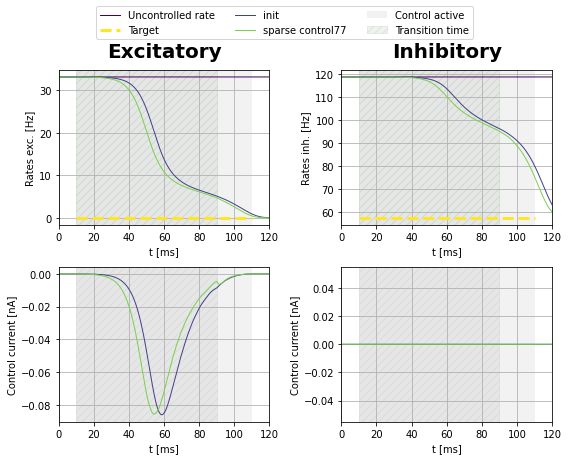

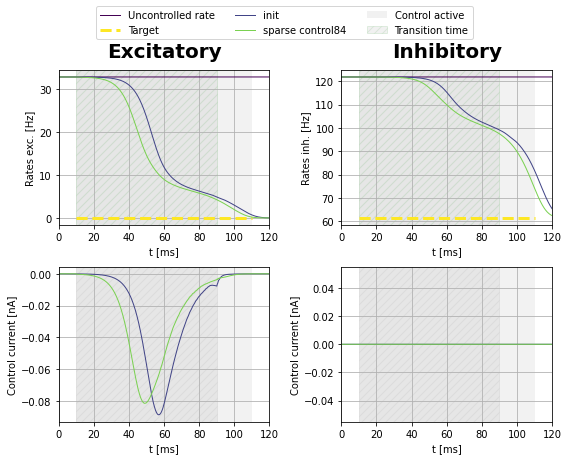

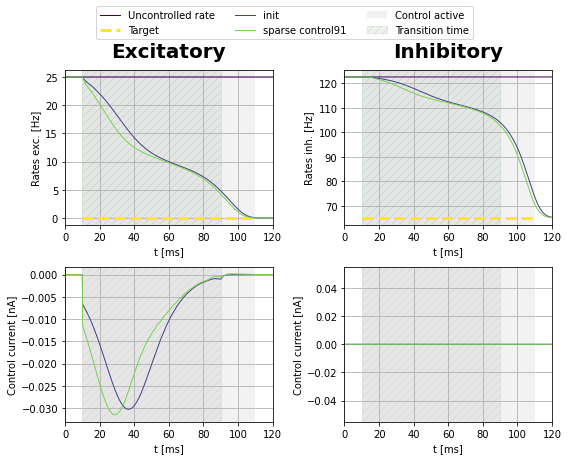

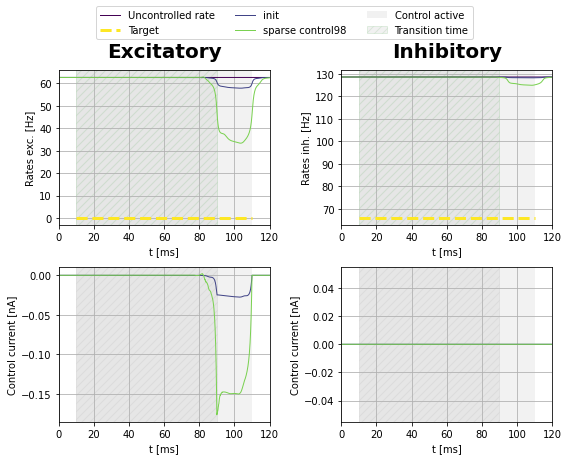

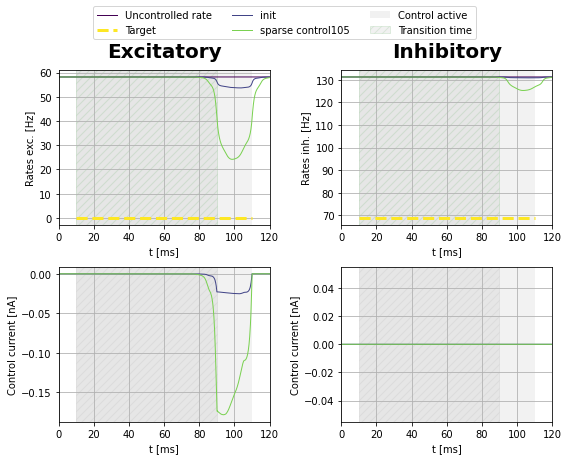

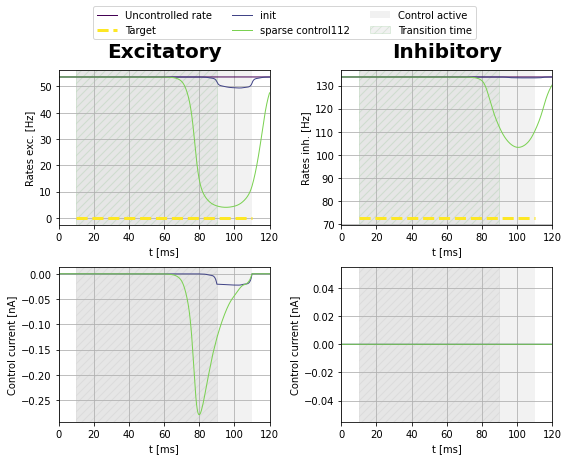

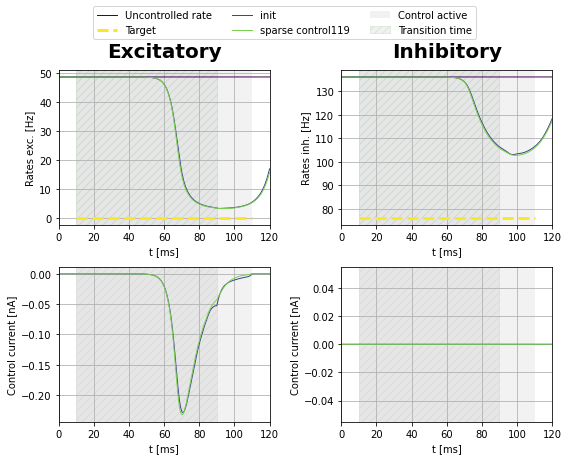

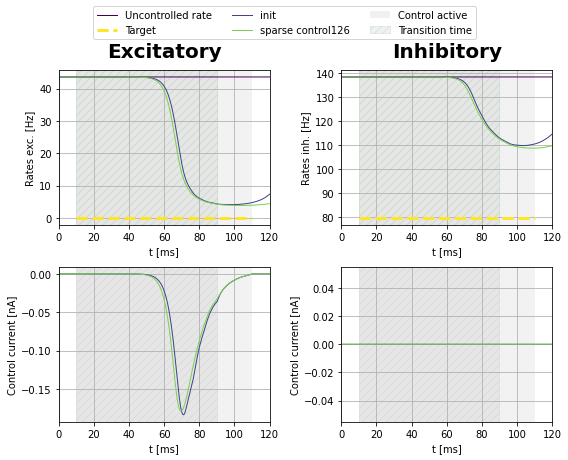

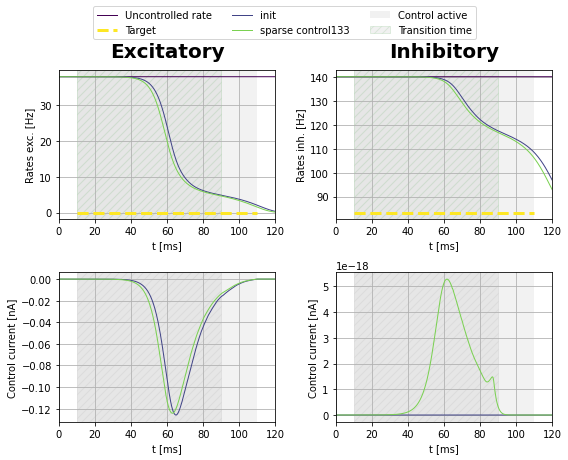

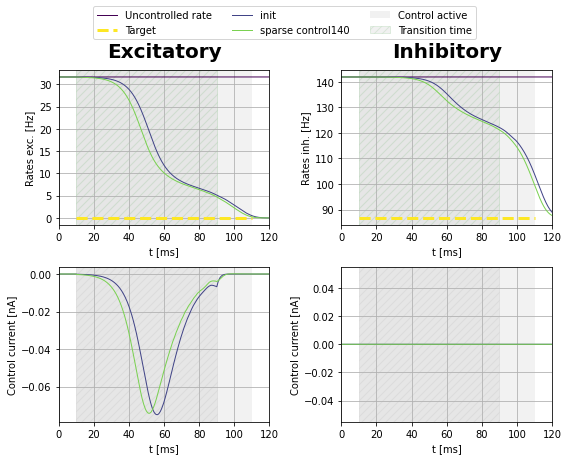

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6694.399286671637
set cost params:  1.0 0.0 6694.399286671637
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5900.645991321099
Gradient descend method:  None
RUN  1 , total integrated cost =  5900.635021335593
RUN  2 , total integrated cost =  5900.634976179545
RUN  3 , total integrated cost =  5900.634976143685
RUN  4 , total integrated cost =  5900.634976143305
RUN  5 , total integrated cost =  5900.634976143293


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5900.634976143293
Control only changes marginally.
RUN  6 , total integrated cost =  5900.634976143293
Improved over  6  iterations in  0.9486009310930967  seconds by  0.00018667748959444452  percent.
Problem in initial value trasfer:  Vmean_exc -62.60984560152959 -62.64297677126799
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  5637.169918430909
set cost params:  1.0 0.0 5637.169918430909
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13546.930023824294
Gradient descend method:  None
RUN  1 , total integrated cost =  13546.770681682623
RUN  2 , total integrated cost =  13546.770558146956
RUN  3 , total integrated cost =  13546.770535730884
RUN  4 , total integrated cost =  13546.770535211139
RUN  5 , total integrated cost =  13546.770535211117


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  13546.770535211117
Control only changes marginally.
RUN  6 , total integrated cost =  13546.770535211117
Improved over  6  iterations in  0.9299670364707708  seconds by  0.001177304473387153  percent.
Problem in initial value trasfer:  Vmean_exc -58.18756581192454 -58.18703225941497
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  6229.768951841061
set cost params:  1.0 0.0 6229.768951841061
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8793.697057544978
Gradient descend method:  None
RUN  1 , total integrated cost =  8793.693951090261
RUN  2 , total integrated cost =  8793.693370826815
RUN  3 , total integrated cost =  8793.693238044376
RUN  4 , total integrated cost =  8793.693168804923
RUN  5 , total integrated cost =  8793.693154589737
RUN  6 , total integrated cost =  8793.693154204913
RUN  7 , total integrated cost =  8793.693154202803


...

RUN  6 , total integrated cost =  28711.349894388313
Control only changes marginally.
RUN  6 , total integrated cost =  28711.349894388313
Improved over  6  iterations in  0.9337256904691458  seconds by  0.0002162757466948051  percent.
Problem in initial value trasfer:  Vmean_exc -56.70397171353326 -56.70398381910804
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 100
[[True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.45

ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  17066.155472503484
Control only changes marginally.
RUN  5 , total integrated cost =  17066.155472503484
Improved over  5  iterations in  0.8034197427332401  seconds by  5.8695306393019564e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.68627469327179 -56.686343512751975
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28711.36988761799
Control only changes marginally.
RUN  1 , total integrated cost =  28711.36988761799
Improved over  1  iterations in  0.19687550328671932  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70397171353326 -56.70398381910804
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37.23187905930894
Gradient descend method:  None
RUN  1 , total integrated cost =  1.098865049703068
RUN  2 , total integrated cost =  1.0628080274022715
RUN  3 , total integrated cost =  1.0551625458266045
RUN  4 , total integrated cost =  1.0542092569347643
RUN  5 , total integrated cost =  1.0493483605882215
RUN  6 , total integrated cost =  1.047870745801613
RUN  7 , total integrated cost =  1.0475493543702532
RUN  8 , total integrated cost =  1.0361298185270476
RUN  9 , total integrated cost =  1.033956656673368
RUN  10 , total integrated cost =  1.0339514962061642
RUN  11 , total integrated cost =  1.0339508169091063
RUN  12 , total integrated cost =  1.0339507932513263
RUN  13 , total integrated cost =  1.0339507910403452
RUN  14 , total integrated cost =  1.0339507889626574
RUN  15 , total integrated cost =  1.0339507883174135
RU

ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  1.0339507596851845
RUN  19 , total integrated cost =  1.0339507230420277
RUN  20 , total integrated cost =  1.0339507206550773
Control only changes marginally.
RUN  22 , total integrated cost =  1.0339507206541168
Improved over  22  iterations in  0.557909844443202  seconds by  97.2229424171499  percent.
Problem in initial value trasfer:  Vmean_exc -62.907658502231534 -62.90671158869133
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  149.39702505902807
Gradient descend method:  None
RUN  1 , total integrated cost =  2.7394415217646153
RUN  2 , total integrated cost =  2.739010522084233
RUN  3 , total integrated cost =  2.7099603326106654
RUN  4 , total integrated cost =  2.696493657351631
RUN  5 , total integrated cost =  2.6964259498426477
RUN  6 , total integrated cost =  2.696411393115129
RUN  7 , total integrated cost =  2.696405933248219
RUN  8

ERROR:root:Problem in initial value trasfer


RUN  60 , total integrated cost =  2.686937633346785
Control only changes marginally.
RUN  61 , total integrated cost =  2.686937633346785
Improved over  61  iterations in  1.278302300721407  seconds by  98.20147848842026  percent.
Problem in initial value trasfer:  Vmean_exc -64.28375906018346 -64.28155236436488
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  46.64238968458803
Gradient descend method:  None
RUN  1 , total integrated cost =  1.4775285792051611
RUN  2 , total integrated cost =  1.4774912129660775
RUN  3 , total integrated cost =  1.4774905910216698
RUN  4 , total integrated cost =  1.4774905704934733
RUN  5 , total integrated cost =  1.4774905689324227
RUN  6 , total integrated cost =  1.4774905687872686


...

RUN  5 , total integrated cost =  3.504358389471166
RUN  6 , total integrated cost =  3.4976555712598483
RUN  7 , total integrated cost =  3.497592938030009
RUN  8 , total integrated cost =  3.4975920937805194
RUN  9 , total integrated cost =  3.497592093780519
RUN  10 , total integrated cost =  3.497592093780519
Control only changes marginally.
RUN  10 , total integrated cost =  3.497592093780519
Improved over  10  iterations in  0.2775287479162216  seconds by  97.7962188748047  percent.
Problem in initial value trasfer:  Vmean_exc -70.10480170716792 -70.13222886146865
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  122.17848263939811
Gradient descend method:  None
RUN  1 , total integrated cost =  2.6312606141670414
RUN  2 , total integrated cost =  2.630377790213967
RUN  3 , total integrated cost =  2.626948847023121
RUN  4 , total integrated cost =  2.626718583204784
RUN  5 , t

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  2.5803361921601815
Control only changes marginally.
RUN  26 , total integrated cost =  2.5803356733889804
Improved over  26  iterations in  0.6218577064573765  seconds by  97.88806046887595  percent.
Problem in initial value trasfer:  Vmean_exc -71.92068204193399 -71.9520073173896
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  74.94431406363708
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  1.6641189981288678
RUN  2 , total integrated cost =  1.6626223172550538
RUN  3 , total integrated cost =  1.6626061304082302
RUN  4 , total integrated cost =  1.6626056356203576
RUN  5 , total integrated cost =  1.6626056356203567
RUN  6 , total integrated cost =  1.6626056356203565
RUN  7 , total integrated cost =  1.6626056356203565
Control only changes marginally.
RUN  7 , total integrated cost =  1.6626056356203565
Improved over  7  iterations in  0.2197677344083786  seconds by  97.78154532949812  percent.
Problem in initial value trasfer:  Vmean_exc -73.89247278523497 -73.92687323757032


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.0339507206541168
Gradient descend method:  None
RUN  1 , total integrated cost =  1.0339507206541168
Control only changes marginally.
RUN  1 , total integrated cost =  1.0339507206541168
Improved over  1  iterations in  0.06303571909666061  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -62.907658502231534 -62.90671158869133
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True Tru

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  1.4774905687735622
Control only changes marginally.
RUN  1 , total integrated cost =  1.4774905687735622
Improved over  1  iterations in  0.06472980417311192  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -69.09486337578291 -69.10594227218814
-------  21 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.2434851745097757
Gradient descend method:  None
RUN  1 , total integrated cost =  3.2434851745097757
Control only changes marginally.
RUN  1 , total integrated cost =  3.2434851745097757
Improved over  1  iterations in  0.064101442694664  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -66.91254239046444 -66.92050385874415
-------  28 0.5000000000000002 0.5000000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.91181392076

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  6.642755708051469
Control only changes marginally.
RUN  1 , total integrated cost =  6.642755708051469
Improved over  1  iterations in  0.06441267393529415  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -64.11767809482933 -64.11846780999403
-------  105 0.5750000000000002 0.7750000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6.0423144509411
Gradient descend method:  None
RUN  1 , total integrated cost =  6.0423144509411
Control only changes marginally.
RUN  1 , total integrated cost =  6.0423144509411
Improved over  1  iterations in  0.06398670375347137  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.65075753096077 -65.65958794457406
-------  112 0.5500000000000003 0.8000000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.22653800487133
Grad

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4.2397503652648325
Control only changes marginally.
RUN  1 , total integrated cost =  4.2397503652648325
Improved over  1  iterations in  0.06415401212871075  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -69.0120859153018 -69.03197251682474
-------  126 0.5000000000000002 0.8500000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.497592093780519
Gradient descend method:  None
RUN  1 , total integrated cost =  3.497592093780519
Control only changes marginally.
RUN  1 , total integrated cost =  3.497592093780519
Improved over  1  iterations in  0.06399059854447842  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -70.10480170716792 -70.13222886146865
-------  133 0.47500000000000014 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.58033567338

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  1.6626056356203565
Control only changes marginally.
RUN  1 , total integrated cost =  1.6626056356203565
Improved over  1  iterations in  0.06375736929476261  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.89247278523497 -73.92687323757032
--------------- 21
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
----

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
